In [1]:
INDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv'
BAGNAME = 'test-obs-01'
TOD = 'H1'

Removing task 0 with battery consumption 0.0
Removing task 1 with battery consumption 0.0
Removing task 2 with battery consumption -1098.4265441894531
{3: {'path_length': 21.447217338580614, 'duration': 58.68000000000029, 'battery_cost_actual': 0.49074554443357954, 'battery_cost_bn': 0, 'battery_cost_cm': 0}, 4: {'path_length': 21.447217338580614, 'duration': 69.73000000000002, 'battery_cost_actual': 0.5008163452148295, 'battery_cost_bn': 0, 'battery_cost_cm': 0}, 5: {'path_length': 21.447217338580614, 'duration': 52.473999999999705, 'battery_cost_actual': 0.3515777587890483, 'battery_cost_bn': 0, 'battery_cost_cm': 0}, 6: {'path_length': 17.849999999999998, 'duration': 57.7819999999997, 'battery_cost_actual': 0.372222900390625, 'battery_cost_bn': 0, 'battery_cost_cm': 0}, 7: {'path_length': 17.85, 'duration': 14.409999999999854, 'battery_cost_actual': 0.20403289794921875, 'battery_cost_bn': 0, 'battery_cost_cm': 0}, 8: {'path_length': 4.0, 'duration': 26.141999999999825, 'battery_cost

<BarContainer object of 2 artists>

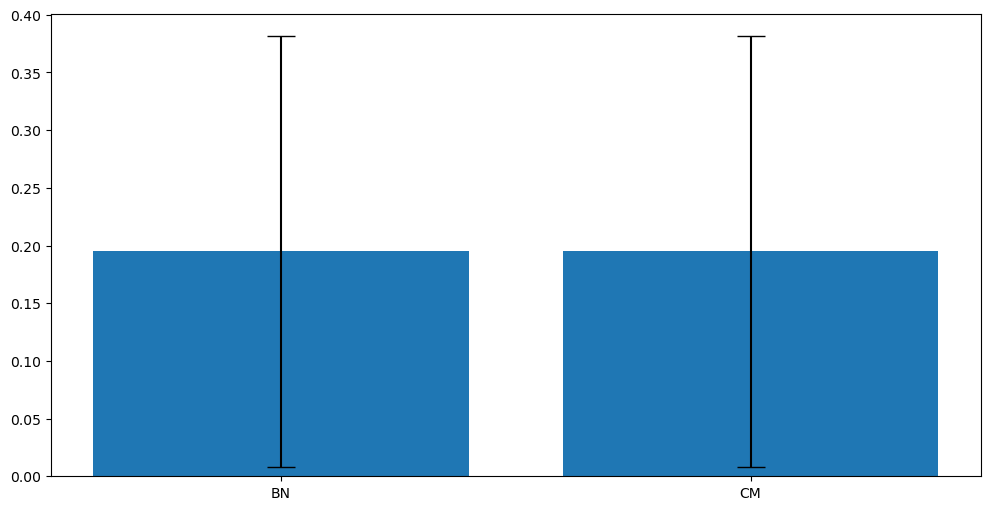

In [2]:
import json
import math
import xml.etree.ElementTree as ET
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

def readScenario():
    # Load and parse the XML file
    tree = ET.parse('/home/lcastri/git/causal-sim2real/HRISim_docker/src/pedsim_ros/pedsim_simulator/scenarios/warehouse.xml')
    root = tree.getroot()
    
    tmp = {}
    for waypoint in root.findall('waypoint'):
        waypoint_id = waypoint.get('id')
        x = float(waypoint.get('x'))
        y = float(waypoint.get('y'))
        r = float(waypoint.get('r'))
        tmp[waypoint_id] = {'x': x, 'y': y, 'r': r}
    return tmp

def pathLength(task):
    return np.sum([
        math.sqrt(
            (WPS_COORD[task['path'][wp_idx]]['x'] - WPS_COORD[task['path'][wp_idx+1]]['x'])**2 + 
            (WPS_COORD[task['path'][wp_idx]]['y'] - WPS_COORD[task['path'][wp_idx+1]]['y'])**2
        )
        for wp_idx in range(len(task['path'])-1)])


WPS_COORD = readScenario()

with open(os.path.join(INDIR, BAGNAME, f'tasks-{TOD}.json')) as pkl_file:
    TASKS = json.load(pkl_file)
TASK_IDs = list(range(TASKS['n_tasks']))
        
df = pd.read_csv(os.path.join(INDIR, BAGNAME, f"{BAGNAME}.csv"))


DTASKS = {task_id: {'path_length': 0,
                   'duration': 0,
                   'battery_cost_actual': 0,
                   'battery_cost_bn': 0,
                   'battery_cost_cm': 0} for task_id in TASK_IDs}
for task_id in TASK_IDs:
    
    start_time = TASKS[str(task_id)]['start']
    end_time = TASKS[str(task_id)]['end']
                
    # Filter the data for the task based on the start and end time
    task_df = df[(df['ros_time'] >= start_time) & (df['ros_time'] <= end_time)]
    
    ## path length
    DTASKS[task_id]['path_length'] = pathLength(TASKS[str(task_id)])
    
    ## actual battery consumption
    battery = task_df['R_B'].to_numpy()
    DTASKS[task_id]['battery_cost_actual'] = battery[0] - battery[-1]
    
    ## estimated battery consumption BN
    DTASKS[task_id]['battery_cost_bn'] = TASKS[str(task_id)]['battery_cost_bn']
    
    # estimated battery consumption CM
    DTASKS[task_id]['battery_cost_cm'] = TASKS[str(task_id)]['battery_cost_cm']
    
    ## duration
    DTASKS[task_id]['duration'] = end_time - start_time
    
    if battery[0] - battery[-1] < -5 or battery[0] - battery[-1] == 0: 
        print(f"Removing task {task_id} with battery consumption {battery[0] - battery[-1]}")
        del DTASKS[task_id]
    
print(DTASKS)

gt = []
bn = []
cm = []
for task_id, task_info in DTASKS.items():
    gt.append(task_info['battery_cost_actual'])
    bn.append(task_info['battery_cost_bn'])
    cm.append(task_info['battery_cost_cm'])
    mae_bn = np.mean(np.abs(np.array(gt) - np.array(bn)))
    mae_cm = np.mean(np.abs(np.array(gt) - np.array(cm)))
    std_bn = np.std(np.abs(np.array(gt) - np.array(bn)))
    std_cm = np.std(np.abs(np.array(gt) - np.array(cm)))

plt.figure(figsize=(12, 6))
plt.bar(['BN', 'CM'], [mae_bn, mae_cm], yerr=[std_bn, std_cm], capsize=10)

